🎉 成功找到檔案！讀取路徑為: ../data/processed/yrbs_cleaned.csv
🕵️‍♂️ 成功解析出的欄位名稱清單: ['Sex_Binary', 'Alcohol_Binary', 'Age_Numeric']
🔥 有效分析樣本數: 12615

📋 === 每個年齡層（不分性別）的有效樣本總筆數整理 ===
🔹 12 歲的總資料筆數: 12 筆
🔹 13 歲的總資料筆數: 6 筆
🔹 14 歲的總資料筆數: 1253 筆
🔹 15 歲的總資料筆數: 2889 筆
🔹 16 歲的總資料筆數: 3252 筆
🔹 17 歲的總資料筆數: 3245 筆
🔹 18 歲的總資料筆數: 1958 筆
📌 12-18 歲不分性別的總樣本數: 12615 筆



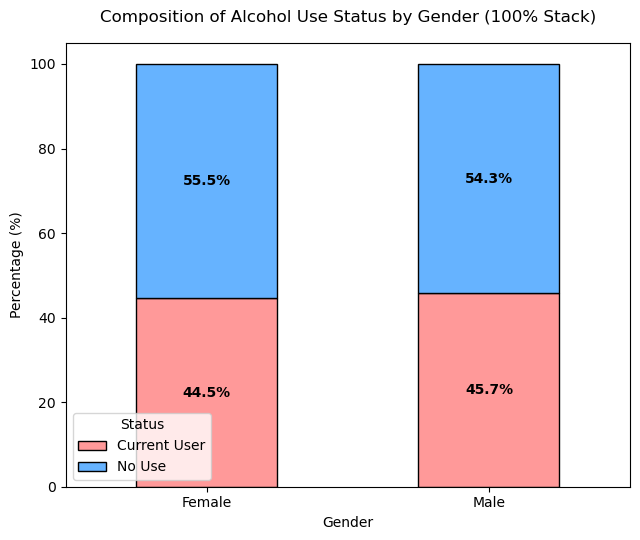


📊 --- 卡方獨立性檢定結果 ---
卡方統計量 (Chi-square Statistic): 1.8152
自由度 (Degrees of Freedom): 1
P 值 (p-value): 1.7788e-01
-----------------------------



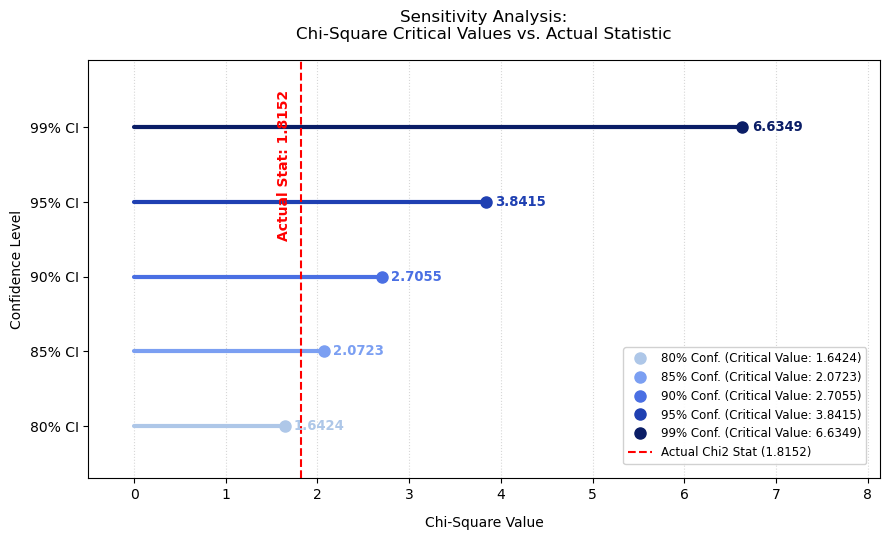

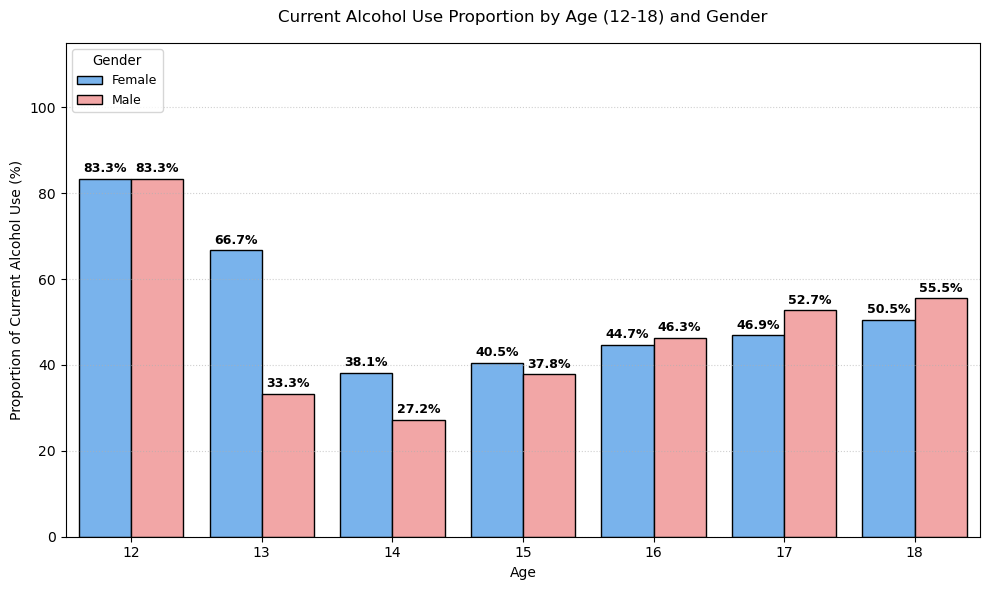

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chi2

# ==========================================
# 1. 自動多路徑尋找已清洗的檔案
# ==========================================
possible_paths = [
    '../data/processed/yrbs_cleaned.csv',  
    'data/processed/yrbs_cleaned.csv',     
    'yrbs_cleaned.csv',                     
    '../yrbs_cleaned.csv'                   
]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        print(f"🎉 成功找到檔案！讀取路徑為: {path}")
        break

if file_path is None:
    raise FileNotFoundError("😭 抱歉，找不到 'yrbs_cleaned.csv'")

# ==========================================
# 2. 使用 utf-8-sig 徹底消滅 BOM 隱形字元
# ==========================================
parsed_rows = []
with open(file_path, 'r', encoding='utf-8-sig') as f:
    for line in f:
        clean_line = line.strip()
        if not clean_line:
            continue
        
        if clean_line.startswith('"') and clean_line.endswith('"'):
            clean_line = clean_line[1:-1]
        else:
            clean_line = clean_line.strip('"')
            
        fields = [field.strip() for field in clean_line.split(',')]
        parsed_rows.append(fields)

headers = parsed_rows[0]
print(f"🕵️‍♂️ 成功解析出的欄位名稱清單: {headers}")

df_final = pd.DataFrame(parsed_rows[1:], columns=headers)

df_final['Sex_Binary'] = pd.to_numeric(df_final['Sex_Binary'], errors='coerce')
df_final['Alcohol_Binary'] = pd.to_numeric(df_final['Alcohol_Binary'], errors='coerce')
df_final['Age_Numeric'] = pd.to_numeric(df_final['Age_Numeric'], errors='coerce')

df_analyzed = df_final[['Sex_Binary', 'Alcohol_Binary', 'Age_Numeric']].dropna()
print(f"🔥 有效分析樣本數: {len(df_analyzed)}")

# ==========================================
# ✨ ✨ 新增功能：整理每個年齡（不分性別）的總資料筆數
# ==========================================
print("\n📋 === 每個年齡層（不分性別）的有效樣本總筆數整理 ===")
df_analyzed['Age_Int'] = df_analyzed['Age_Numeric'].astype(int)
age_counts = df_analyzed[df_analyzed['Age_Int'].between(12, 18)]['Age_Int'].value_counts().sort_index()

for age, count in age_counts.items():
    print(f"🔹 {age} 歲的總資料筆數: {count} 筆")
print(f"📌 12-18 歲不分性別的總樣本數: {age_counts.sum()} 筆")
print("="*50 + "\n")


out_dir = '../outputs/figures/' if os.path.exists('../outputs/') else 'outputs/figures/'
os.makedirs(out_dir, exist_ok=True)

df_plot = df_analyzed.copy()
df_plot['Gender'] = df_plot['Sex_Binary'].map({0: 'Male', 1: 'Female'})
df_plot['Alcohol_Status'] = df_plot['Alcohol_Binary'].map({0: 'No Use', 1: 'Current User'})
df_plot['Age'] = df_plot['Age_Numeric'].astype(int)

# ==========================================
# ✨ 圖表 1：100% 堆疊百分比長條圖
# ==========================================
plt.figure(figsize=(6.5, 5.5))
cross_tab = pd.crosstab(df_plot['Gender'], df_plot['Alcohol_Status'], normalize='index') * 100
cross_tab.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], edgecolor='black', ax=plt.gca())
plt.title('Composition of Alcohol Use Status by Gender (100% Stack)', fontsize=12, pad=15)
plt.ylabel('Percentage (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.legend(title='Status', loc='lower left')

for i in range(len(cross_tab)):
    no_use_val = cross_tab.iloc[i, 0]
    user_val = cross_tab.iloc[i, 1]
    plt.text(i, no_use_val / 2, f'{no_use_val:.1f}%', ha='center', va='center', color='black', fontweight='bold')
    plt.text(i, no_use_val + (user_val / 2), f'{user_val:.1f}%', ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'stacked_alcohol_gender.png'), dpi=300)
plt.show()

# ==========================================
# ✨ 圖表 2：卡方檢定臨界值敏感度分析圖
# ==========================================
contingency_table = pd.crosstab(df_analyzed['Sex_Binary'], df_analyzed['Alcohol_Binary'])
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"\n📊 --- 卡方獨立性檢定結果 ---")
print(f"卡方統計量 (Chi-square Statistic): {chi2_stat:.4f}")
print(f"自由度 (Degrees of Freedom): {dof}")
print(f"P 值 (p-value): {p_val:.4e}")
print(f"-----------------------------\n")

confidence_levels = [0.80, 0.85, 0.90, 0.95, 0.99]
colors = ['#aec7e8', '#7b9ff2', '#4a6fe3', '#1f40b2', '#0a1d66'] 

plt.figure(figsize=(9, 5.5))
for idx, cl in enumerate(confidence_levels):
    alpha = 1 - cl
    critical_value = chi2.ppf(1 - alpha, dof)
    
    plt.plot([0, critical_value], [idx, idx], color=colors[idx], linewidth=3, solid_capstyle='round')
    plt.plot(critical_value, idx, 'o', color=colors[idx], markersize=8, 
             label=f'{int(cl*100)}% Conf. (Critical Value: {critical_value:.4f})')
    
    plt.text(critical_value + 0.1, idx, f'{critical_value:.4f}', ha='left', va='center', 
             color=colors[idx], fontsize=9.5, fontweight='bold')

plt.axvline(x=chi2_stat, color='red', linestyle='--', linewidth=1.5, label=f'Actual Chi2 Stat ({chi2_stat:.4f})')
plt.text(chi2_stat - 0.1, len(confidence_levels) - 0.5, f'Actual Stat: {chi2_stat:.4f}', 
         color='red', ha='right', va='top', fontweight='bold', rotation=90)

plt.title('Sensitivity Analysis:\nChi-Square Critical Values vs. Actual Statistic', fontsize=12, pad=15)
plt.xlabel('Chi-Square Value', labelpad=10)
plt.ylabel('Confidence Level')
plt.yticks(range(len(confidence_levels)), [f'{int(cl*100)}% CI' for cl in confidence_levels])

plt.xlim(-0.5, max(chi2_stat, chi2.ppf(0.99, dof)) + 1.5)
plt.ylim(-0.7, len(confidence_levels) - 0.1)

# 💡 完美防遮擋：縮小圖例並推至最右下角，不擋到任何線條與數據標籤
plt.legend(loc='lower right', bbox_to_anchor=(0.99, 0.02), fontsize=8.5, framealpha=0.9)

plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'confidence_interval_diff.png'), dpi=300)
plt.show()

# ==========================================
# ✨ 圖表 3：12-18 歲飲酒比例趨勢圖
# ==========================================
df_age_plot = df_plot[df_plot['Age'].between(12, 18)]
age_gender_stats = df_age_plot.groupby(['Age', 'Gender'])['Alcohol_Binary'].mean().reset_index()
age_gender_stats['Percentage'] = age_gender_stats['Alcohol_Binary'] * 100

plt.figure(figsize=(10, 6)) 
ax = sns.barplot(x='Age', y='Percentage', hue='Gender', data=age_gender_stats,
                 palette=['#66b3ff', '#ff9999'], edgecolor='black')

plt.title('Current Alcohol Use Proportion by Age (12-18) and Gender', fontsize=12, pad=15)
plt.ylabel('Proportion of Current Alcohol Use (%)')
plt.xlabel('Age')
plt.ylim(0, 115) 

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.text(p.get_x() + p.get_width()/2., height + 1.5, f'{height:.1f}%',
                ha="center", fontsize=9, fontweight='bold') 

plt.legend(title='Gender', loc='upper left', fontsize=9, title_fontsize=9.5)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'alcohol_by_gender_and_age.png'), dpi=300)
plt.show()